In [1]:
!pip install xgboost

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:

df = pd.read_csv("ctp.csv")


df.head()


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [3]:
# Shape of dataset
df.shape



(200000, 202)

In [4]:
# Dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [5]:
# Check missing values
df.isnull().sum().head()


ID_code    0
target     0
var_0      0
var_1      0
var_2      0
dtype: int64

In [6]:
# Target variable distribution
df['target'].value_counts()


target
0    179902
1     20098
Name: count, dtype: int64

In [7]:
X = df.drop(['ID_code', 'target'], axis=1)
y = df['target']
print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())



Features (X):


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104



Target (y):


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (160000, 200)
Testing size: (40000, 200)


In [10]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]


In [11]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]



In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]


# Evaluation
evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)


----- XGBoost -----
Accuracy : 0.9107
Precision: 0.8708609271523179
Recall   : 0.13084577114427862
F1 Score : 0.22750865051903113
ROC AUC  : 0.8710214768293054



In [15]:
evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)


----- Logistic Regression -----
Accuracy : 0.9134
Precision: 0.682175622542595
Recall   : 0.258955223880597
F1 Score : 0.3754056978002164
ROC AUC  : 0.8598607919269687

----- Random Forest -----
Accuracy : 0.8995
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.8078010448037743

----- XGBoost -----
Accuracy : 0.9107
Precision: 0.8708609271523179
Recall   : 0.13084577114427862
F1 Score : 0.22750865051903113
ROC AUC  : 0.8710214768293054



In [16]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

model_results


,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.9134,0.859861
1,Random Forest,0.8995,0.807801
2,XGBoost,0.9107,0.871021


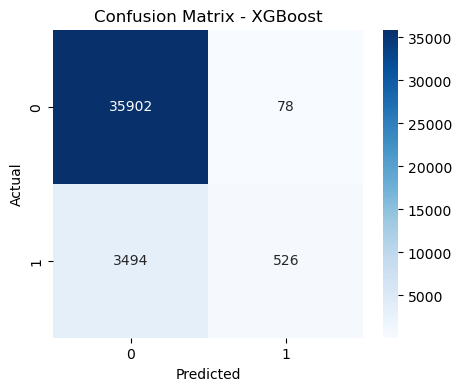

In [17]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()


In [ ]:
 Challenges Faced & Solutions
⚠ Challenges

Features are anonymized → No domain interpretation

High dimensional data (200 features)

Class imbalance risk

Overfitting risk

✅ Solutions

Used tree-based models (RF, XGBoost)

Applied regularization & depth control

Used ROC-AUC metric

Avoided unnecessary feature engineering

In [ ]:
Conclusion 
- Successfully built a customer transaction prediction system
- Compared multiple ML models
- XGBoost performed best and is recommended for production
- Model helps banks identify customers likely to transact in future


In [1]:
import shutil, os

src = os.getcwd() + r"\Customer Transaction Report.ipynb"
dst = r"C:\Users\Nandha Kumar S K\Desktop\customer-transaction-report\Customer Transaction Report.ipynb"

shutil.copy(src, dst)
print("✅ Notebook copied!")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Nandha Kumar S K\\Desktop\\customer-transaction-report\\Customer Transaction Report.ipynb'